In [13]:
import numpy as np
import math
import matplotlib.pyplot as plt
def grs(e1, e2, e3, r):
    p = math.log(np.abs(e1-e2)/np.abs(e2-e3)) / math.log(r)
    return p

In [14]:
print(grs(0.00359899, 0.00298943, 0.00242438, 1.414))

0.21887477818865583


In [15]:
def grs1(e1, e2, r):
    p = math.log(e1/e2) / math.log(r)
    return p

In [19]:
print(grs1(0.00242439, 0.00193053,1.414))

0.6575361743847417


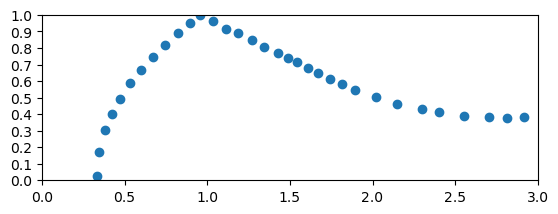

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.pyplot import MultipleLocator


data = pd.read_csv('t1.csv')

x = data['x']
y = data['y']


x_major_locator = MultipleLocator(0.5)
y_major_locator = MultipleLocator(0.1)

plt.gca().set_aspect('equal', adjustable='box')
plt.xlim(0, 3)
plt.ylim(0, 1)
plt.xticks(np.arange(0, 3.0, 0.5))
plt.yticks(np.arange(0, 1.0, 0.1))
plt.scatter(x, y, marker='o')
plt.gca().xaxis.set_major_locator(x_major_locator)
plt.gca().yaxis.set_major_locator(y_major_locator)


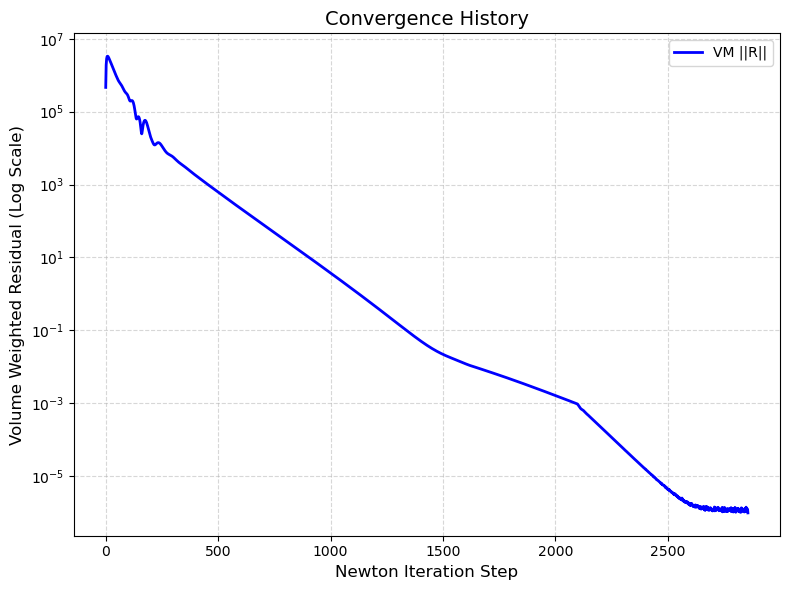

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame()
try:
    df = pd.read_csv("residual_history.csv")
    df.columns = df.columns.str.strip()  # Remove any leading/trailing whitespace from column names
except FileNotFoundError:
    print("Error: Could not find 'residual_history.csv'. Have you run your C++ solver?")
    exit()


step = df["Step"]
residual = df["Residual_VM"]


plt.figure(figsize=(8, 6))
plt.plot(step, residual, 'b-', linewidth=2, label="VM ||R||")


plt.yscale('log')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.title("Convergence History", fontsize=14)
plt.xlabel("Newton Iteration Step", fontsize=12)
plt.ylabel("Volume Weighted Residual (Log Scale)", fontsize=12)
plt.legend()

plt.tight_layout()
plt.savefig("convergence_history.png", dpi=300)
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 读取边界层分布
try:
    df_bl = pd.read_csv("bl_profile.csv")
except FileNotFoundError:
    print("Error: Could not find 'bl_profile.csv'.")
    raise

# 对数据按照 y 坐标排序，保证画线时点是按顺序连起来的
df_bl = df_bl.sort_values(by="y")

eta = df_bl["eta"]
u_uinf = df_bl["u"]
v_uinf = df_bl["v"]

# 绘制图形
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# 图1: u 速度剖面
ax1.plot(u_uinf, eta, 'bo-', markersize=4, label='Numerical U')
ax1.set_xlabel(r'$u / U_{\infty}$', fontsize=12)
ax1.set_ylabel(r'$\eta = y \sqrt{U_{\infty} / \nu x}$', fontsize=12)
ax1.set_title("Streamwise Velocity Profile", fontsize=14)
ax1.set_ylim(0, 8)  # Blasius 解在 eta=5 左右到达边界层外缘
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# 图2: v 速度剖面
ax2.plot(v_uinf, eta, 'ro-', markersize=4, label='Numerical V')
ax2.set_xlabel(r'$v / U_{\infty}$', fontsize=12)
ax2.set_ylabel(r'$\eta$', fontsize=12)
ax2.set_title("Normal Velocity Profile", fontsize=14)
ax2.set_ylim(0, 8)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.savefig("blasius_comparison.png", dpi=300)
plt.show()